# WCS 04 — Local WCS Orientation & Jacobian

**What this notebook tests:**
The most important question for later spectral-angle extraction: how much does the local sky orientation change across the detector?

A global rotation correction is only valid if the WCS Jacobian is approximately uniform. If the local orientation varies significantly with field position (due to lens distortion, field rotation, or SIP distortion), each spectral trace must be corrected individually using its own local Jacobian.

**Method:** At each grid point `(x, y)`, take finite-difference displacements `(x±dx, y)` and `(x, y±dy)`, convert all to sky coordinates, and estimate the local 2×2 pixel→sky Jacobian from the results.

In [1]:
import sys
from pathlib import Path
import warnings
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

from astropy.io import fits as afits
from astropy.wcs import WCS
import astropy.units as u

OUT_DIR = ROOT / 'out' / 'wcs_diagnostics'
CACHE   = OUT_DIR / 'platesolve_result.pkl'

if not CACHE.exists():
    raise FileNotFoundError('Run wcs_01 first')
with open(CACHE, 'rb') as f:
    result = pickle.load(f)

with afits.open(sorted((ROOT / 'data').glob('*.fit'))[0]) as hdul:
    image = hdul[0].data.astype(float)

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    wcs = WCS(result.header)

h, w = image.shape
print(f'Image: {w} × {h} px')

Image: 3096 × 2080 px


In [2]:
def local_jacobian(wcs, x, y, step=1.0):
    """
    Compute the local 2x2 sky Jacobian at pixel (x, y).

    Returns J where J @ [dpx, dpy] ≈ [dra_cosdec, ddec] in degrees.
    Uses a symmetric finite difference with step pixels.
    """
    pts = np.array([[x - step, y], [x + step, y],
                    [x, y - step], [x, y + step]])
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        sky = wcs.pixel_to_world_values(pts[:, 0], pts[:, 1])
    ra, dec = sky
    # Apply cos(dec) so RA offset is a true angular offset
    cos_d = np.cos(np.radians(dec.mean()))
    dra_dx  = (ra[1]  - ra[0])  * cos_d / (2 * step)
    ddec_dx = (dec[1] - dec[0])           / (2 * step)
    dra_dy  = (ra[3]  - ra[2])  * cos_d / (2 * step)
    ddec_dy = (dec[3] - dec[2])           / (2 * step)
    return np.array([[dra_dx, dra_dy], [ddec_dx, ddec_dy]])


def local_orientation(J):
    """
    From pixel→sky Jacobian J, extract:
      - angle of the pixel +x axis on sky (degrees CCW from East = +RA direction)
      - local plate scale in x and y (arcsec/px)
    Returns (angle_x_deg, scale_x_as, scale_y_as)
    """
    # Column 0 of J is sky displacement per pixel in +x direction
    dra_x, ddec_x = J[0, 0], J[1, 0]
    angle_x = np.degrees(np.arctan2(ddec_x, dra_x))   # CCW from East (+RA)
    scale_x  = np.hypot(dra_x, ddec_x) * 3600          # arcsec/px
    dra_y, ddec_y = J[0, 1], J[1, 1]
    scale_y  = np.hypot(dra_y, ddec_y) * 3600
    return angle_x, scale_x, scale_y


# Build a grid
GRID = 12   # grid points per axis
xs = np.linspace(w * 0.05, w * 0.95, GRID)
ys = np.linspace(h * 0.05, h * 0.95, GRID)
XX, YY = np.meshgrid(xs, ys)

angles  = np.zeros_like(XX)
scale_x = np.zeros_like(XX)
scale_y = np.zeros_like(XX)
north_u  = np.zeros_like(XX)   # unit vector toward North in pixel frame
north_v  = np.zeros_like(XX)
east_u   = np.zeros_like(XX)
east_v   = np.zeros_like(XX)

for i in range(GRID):
    for j in range(GRID):
        x, y = float(XX[i, j]), float(YY[i, j])
        J = local_jacobian(wcs, x, y, step=5.0)
        ang, sx, sy = local_orientation(J)
        angles[i, j] = ang
        scale_x[i, j] = sx
        scale_y[i, j] = sy
        # North in pixel frame: direction that increases Dec
        # J = [[dRA/dpx, dRA/dpy], [dDec/dpx, dDec/dpy]]
        # North column = J^{-1} @ [0, 1] (direction where Dec increases per pixel)
        try:
            Jinv = np.linalg.inv(J)
            north_dir = Jinv @ np.array([0.0, 1.0])
            east_dir  = Jinv @ np.array([1.0, 0.0])
            north_dir /= np.linalg.norm(north_dir)
            east_dir  /= np.linalg.norm(east_dir)
        except np.linalg.LinAlgError:
            north_dir = east_dir = np.array([0.0, 0.0])
        north_u[i, j], north_v[i, j] = north_dir
        east_u[i, j],  east_v[i, j]  = east_dir

# Angle at image centre
cx_idx = GRID // 2
angle_center = angles[cx_idx, cx_idx]
angle_delta  = angles - angle_center
print(f'Local angle at centre           : {angle_center:.4f}°')
print(f'Angle variation (min/max/std)    : {angle_delta.min():.4f}° / {angle_delta.max():.4f}° / {angle_delta.std():.4f}°')
print(f'Scale x (arcsec/px) min/max      : {scale_x.min():.3f} / {scale_x.max():.3f}')
print(f'Scale y (arcsec/px) min/max      : {scale_y.min():.3f} / {scale_y.max():.3f}')

Local angle at centre           : -161.5737°
Angle variation (min/max/std)    : -18.3181° / 341.2874° / 96.9773°
Scale x (arcsec/px) min/max      : 55.178 / 80.782
Scale y (arcsec/px) min/max      : 62.418 / 81.089


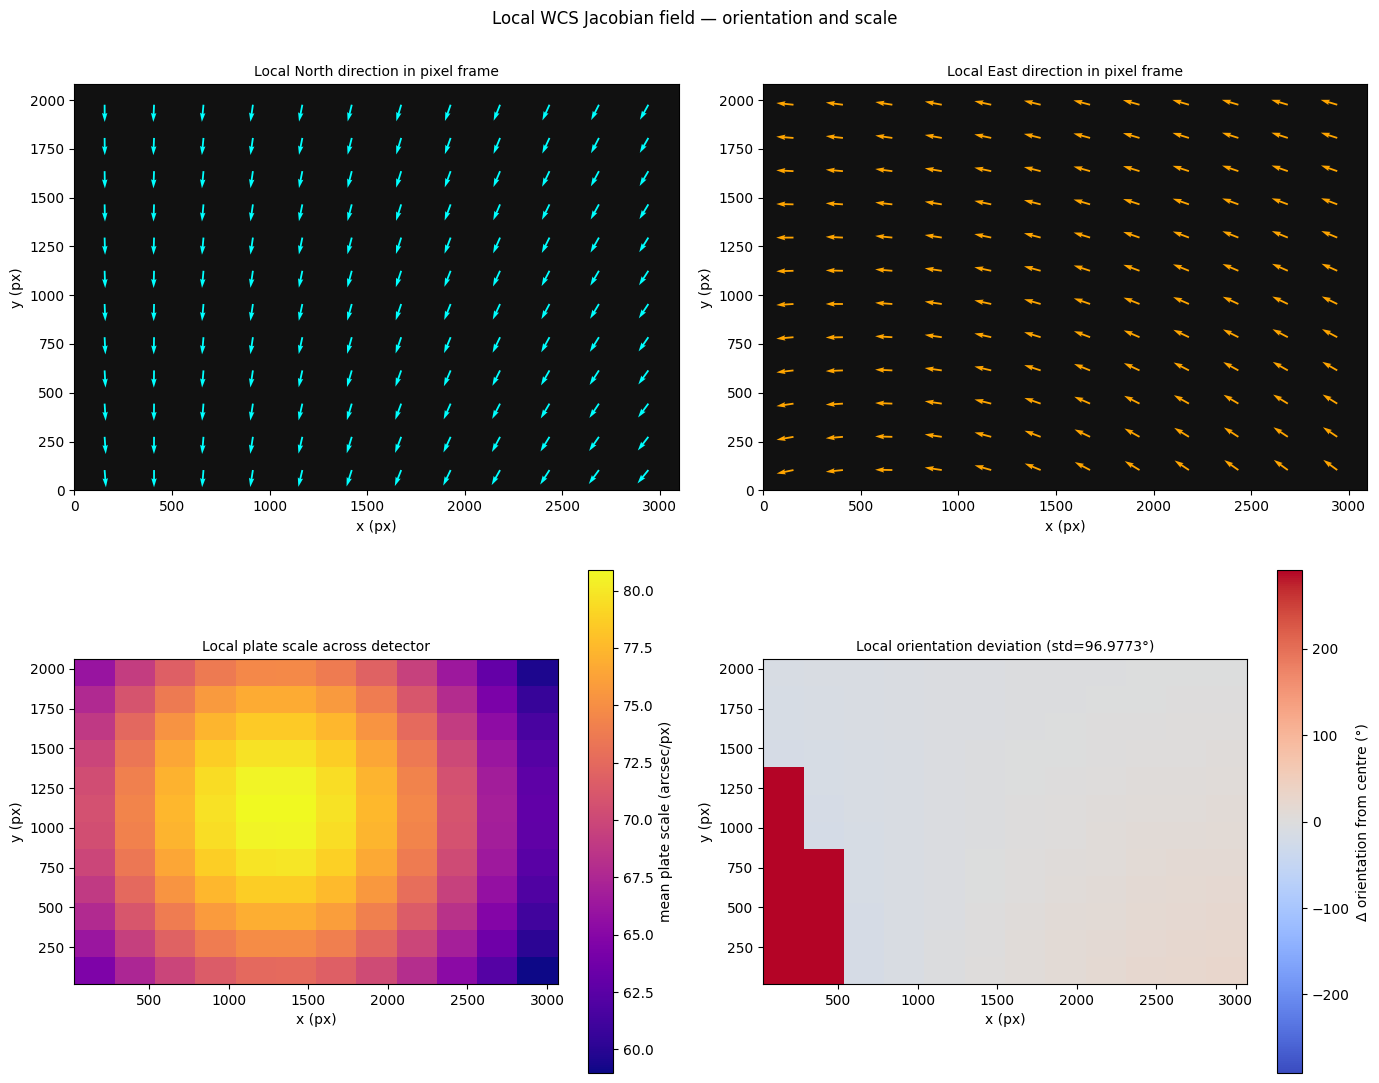

Saved wcs04_local_jacobian.png


In [3]:
ARROW_SCALE = 35.0   # normalised arrow length for quiver

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# 1. North arrows
ax = axes[0, 0]
ax.set_facecolor('#111')
ax.imshow(np.zeros_like(image), cmap='gray', origin='lower', alpha=0)
q = ax.quiver(XX, YY, north_u, north_v, color='cyan', scale=ARROW_SCALE,
              scale_units='width', width=0.003)
ax.set_xlim(0, w); ax.set_ylim(0, h); ax.set_aspect('equal')
ax.set_title('Local North direction in pixel frame', fontsize=10)
ax.set_xlabel('x (px)'); ax.set_ylabel('y (px)')

# 2. East arrows
ax = axes[0, 1]
ax.set_facecolor('#111')
q = ax.quiver(XX, YY, east_u, east_v, color='orange', scale=ARROW_SCALE,
              scale_units='width', width=0.003)
ax.set_xlim(0, w); ax.set_ylim(0, h); ax.set_aspect('equal')
ax.set_title('Local East direction in pixel frame', fontsize=10)
ax.set_xlabel('x (px)'); ax.set_ylabel('y (px)')

# 3. Local scale map (arcsec/px)
ax = axes[1, 0]
mean_scale = (scale_x + scale_y) / 2
im = ax.pcolormesh(XX, YY, mean_scale, cmap='plasma')
plt.colorbar(im, ax=ax, label='mean plate scale (arcsec/px)')
ax.set_aspect('equal')
ax.set_title('Local plate scale across detector', fontsize=10)
ax.set_xlabel('x (px)'); ax.set_ylabel('y (px)')

# 4. Orientation deviation from centre
ax = axes[1, 1]
im2 = ax.pcolormesh(XX, YY, angle_delta, cmap='coolwarm',
                     norm=Normalize(vmin=-angle_delta.std()*3, vmax=angle_delta.std()*3))
plt.colorbar(im2, ax=ax, label='Δ orientation from centre (°)')
ax.set_aspect('equal')
ax.set_title(f'Local orientation deviation (std={angle_delta.std():.4f}°)', fontsize=10)
ax.set_xlabel('x (px)'); ax.set_ylabel('y (px)')

fig.suptitle('Local WCS Jacobian field — orientation and scale', fontsize=12)
plt.tight_layout()
plt.savefig(OUT_DIR / 'wcs04_local_jacobian.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved wcs04_local_jacobian.png')

## Interpretation

**Key metric:** The orientation deviation from centre (plot 4) shows directly how much the naïve global-rotation correction would be wrong at each point in the field.

**Good outcome:** Orientation variation < 0.1° across the full field → a single global rotation offset is sufficient; angle extraction can use the image-centre Jacobian for all traces.

**Needs local correction:** Variation > 0.1° (especially with a coherent pattern like radial or barrel distortion) → must use per-trace local Jacobian (`pixel_angle_to_sky_angle(wcs, x, y, theta)` from the planned `wcs_geometry.py`).

**Scale variation:** If scale_x and scale_y differ significantly, the detector has anamorphic distortion; this also affects angle extraction and must be handled in the Jacobian transform.

**Note on SIP vs plain TAN:** If wcs_01 showed no SIP terms, the WCS Jacobian here is a global affine transform (constant across the field). Any real distortion in the lens is then unmodelled, meaning the actual local Jacobian varies more than what this notebook shows. The SIP coefficients encode the field-dependent correction; without them these plots underestimate the true variation.